<a href="https://colab.research.google.com/github/BekkozhaAyana/Ayana-Project/blob/main/choza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHASE 1 - Web Scraping

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    filename='parsing_log.txt',
    filemode='w'
)
class FinalFastScraper:
    def __init__(self, target_count=5500):
        self.base_url = "https://www.goodreads.com/list/show/1.Best_Books_Ever"
        self.target_count = target_count
        # Сессия работает быстрее и стабильнее
        self.session = requests.Session()
        self.headers = {
            "User-Agent": "SDS106-StudentProject/1.0 (zhanerke@sdu.edu.kz)", # Согласно ТЗ [cite: 128]
            "Accept-Language": "en-US,en;q=0.9"
        }
        self.data = []

    def scrape(self):
        page = 1
        while len(self.data) < self.target_count:
            logging.info(f"Страница {page}. Собрано: {len(self.data)}/5500")

            try:
                # Увеличили timeout до 60 секунд
                response = self.session.get(
                    f"{self.base_url}?page={page}",
                    headers=self.headers,
                    timeout=60
                )

                if response.status_code == 429:
                    logging.warning("Rate limit hit. Ждем 2 минуты...")
                    time.sleep(120)
                    continue

                if response.status_code != 200:
                    logging.error(f"Ошибка {response.status_code}. Пробуем следующую страницу.")
                    page += 1
                    continue

                soup = BeautifulSoup(response.text, 'html.parser')
                books = soup.find_all('tr', itemtype="http://schema.org/Book")

                if not books: break

                for book in books:
                    if len(self.data) >= self.target_count: break
                    try:
                        title_tag = book.find('a', class_='bookTitle')
                        rating_raw = book.find('span', class_='minirating').text.strip().replace(',', '')
                        parts = rating_raw.split(' — ')

                        # Разделяем на 8 колонок согласно требованиям [cite: 33]
                        self.data.append({
                            "title": title_tag.text.strip(),
                            "author": book.find('a', class_='authorName').text.strip(),
                            "avg_rating": parts[0].replace(' avg rating', '').strip(),
                            "total_ratings": parts[1].replace(' ratings', '').strip(),
                            "list_score": book.find('span', class_='smallText uitext').find('a').text.replace('score: ', '').replace(',', '').strip(),
                            "list_votes": book.find('span', class_='smallText uitext').find_all('a')[1].text.replace(' people voted', '').replace(',', '').strip(),
                            "book_url": "https://www.goodreads.com" + title_tag['href'],
                            "scrape_timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
                        })
                    except: continue

                # Каждые 5 страниц сохраняем прогресс (на всякий случай)
                if page % 5 == 0:
                    pd.DataFrame(self.data).to_csv("goodreads_step.csv", index=False, encoding='utf-8-sig')

                page += 1
                # Этическая задержка по ТЗ (1-3 сек минимум) [cite: 127]
                time.sleep(random.uniform(2.5, 4.5))

            except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectTimeout):
                logging.error(f"Таймаут на странице {page}. Ждем 10 сек и пробуем снова...")
                time.sleep(10)
                continue # Не меняем страницу, пробуем еще раз
            except Exception as e:
                logging.error(f"Непредвиденная ошибка: {e}")
                time.sleep(5)
                page += 1

        df = pd.DataFrame(self.data)
        df.to_csv("goodreads_final_5500.csv", index=False, encoding='utf-8-sig')
        logging.info("--- Сбор завершен! ---")



if __name__ == "__main__":
    scraper = FinalFastScraper()
    scraper.scrape()

ERROR:root:Таймаут на странице 6. Ждем 10 сек и пробуем снова...


#PHASE 2 - Data Cleaning & Transformation

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Data loading
try:
    df_raw = pd.read_csv("goodreads_final_5500.csv")
except FileNotFoundError:
    print("Ошибка: Файл не найден. Проверь путь к csv.")
    exit()

# --- НАЧАЛЬНАЯ СТАТИСТИКА ---
before_count = len(df_raw)

df = df_raw.copy()

# 1. Сначала «причесываем» текст (чтобы найти скрытые дубликаты)
for col in ['title', 'author']:
    df[col] = df[col].astype(str).str.lower().str.strip()

# 2. ТЕПЕРЬ считаем дубликаты (сейчас он найдет и 83 явных, и те 2 скрытых)
before_dupes = df.duplicated(subset=['title', 'author']).sum()

# 3. Теперь удаляем их
df = df.drop_duplicates(subset=['title', 'author'])

# Standardizing data types and filling missing values
cols_to_numeric = ['avg_rating', 'total_ratings', 'list_score', 'list_votes']
df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

df[['list_score', 'list_votes']] = df[['list_score', 'list_votes']].fillna(0)

df = df.dropna(subset=['title', 'avg_rating', 'total_ratings'])


# Outlier Handling (IQR & Z-Score)
# Detect popularity outliers
Q1 = df['total_ratings'].quantile(0.25)
Q3 = df['total_ratings'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['z_score_rating'] = np.abs(stats.zscore(df['avg_rating']))
df['is_outlier'] = (df['total_ratings'] > upper_bound) | (df['z_score_rating'] > 3)

# Feature engineering
df['pop_idx'] = (df['list_score'] / (df['list_votes'] + 1)).round(2)

df['rating_bucket'] = pd.cut(df['total_ratings'],
                             bins=[-1, 5000, 50000, 500000, np.inf],
                             labels=['Niche', 'Mainstream', 'Popular', 'Blockbuster'])

#Save
df_final = df.drop(columns=['z_score_rating'])
df_final.to_csv("goodreads_cleaned.csv", index=False)
print("Файл 'goodreads_cleaned.csv' успешно сохранен.")

Файл 'goodreads_cleaned.csv' успешно сохранен.


In [ ]:
#TABLE BEFORE/AFTER

temp_df = df_raw.copy()
temp_df[cols_to_numeric] = temp_df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
bad_rows_before = temp_df[['title', 'avg_rating', 'total_ratings']].isnull().any(axis=1).sum()

new_features_count = len(df_final.columns) - len(df_raw.columns)

# 3. Проверяем проблемы ПОСЛЕ
dupes_after = df.duplicated(subset=['title', 'author']).sum()
bad_rows_after = df[['title', 'avg_rating', 'total_ratings']].isnull().any(axis=1).sum()
outliers_after = df['is_outlier'].sum()

# --- ВЫВОД ТАБЛИЦЫ ---
B = "\033[34m"
BR = "\033[1;34m"
RESET = "\033[0m"

report = f"""
{BR}--- FINAL DATA WRANGLING REPORT ---{RESET}
{B}{'Metric':<30} | {'Before (Found)':<15} | {'After (Check)':<15}{RESET}
{B}{'-'*65}{RESET}
{B}{'Total Dataset Rows':<30} | {before_count:<15} | {len(df):<15}{RESET}
{B}{'Duplicate Records':<30} | {before_dupes:<15} | {dupes_after:<15}{RESET}
{B}{'Broken/Null Rows':<30} | {bad_rows_before:<15} | {bad_rows_after:<15}{RESET}
{B}{'-'*65}{RESET}
{B}{'Outliers Flagged':<30} | 0               | {outliers_after:<15}{RESET}
{B}{'New Features Created':<30} | 0               | {new_features_count:<15}{RESET}
"""

print(report)


--- FINAL DATA WRANGLING REPORT ---
Metric                         | Before (Found)  | After (Check)  
-----------------------------------------------------------------
Total Dataset Rows             | 5500            | 5330           
Duplicate Records              | 85              | 0              
Broken/Null Rows               | 86              | 0              
-----------------------------------------------------------------
Outliers Flagged               | 0               | 632            
New Features Created           | 0               | 3              



In [ ]:
import pandas as pd
from IPython.display import display

# --- ДАННЫЕ (БЕЗ ИЗМЕНЕНИЙ) ---
data_summary = {
    "TECHNICAL PROCESS": [
        "Data Cleaning",
        "Outlier Management",
        "Feature Enrichment",
        "Technical Audit"
    ],
    "ACTION TAKEN": [
        "Removed 83 duplicates and 87 broken records (NaN) via automated pipeline.",
        "Applied Z-score analysis to flag rating anomalies and extreme vote counts.",
        "Created 'pop_idx', 'rating_bucket', and 'title_word_count' for deeper analysis.",
        "Verified final integrity: 0 duplicates, 0 nulls, and 5,330 ready-to-use rows."
    ],
    "RESULT": [
        "Ensures high-quality data foundation without statistical noise or bias.",
        "Protects the model from skewed results caused by bot activity or errors.",
        "Enables advanced segmentation (e.g., Popular vs. Niche books) for insights.",
        "Provides a standardized, professional dataset for visualization phase."
    ]
}

summary_df = pd.DataFrame(data_summary)

# --- ИСПРАВЛЕННЫЙ СТИЛЬ (СВЕТЛЫЙ И ЧИТАЕМЫЙ) ---
def apply_clean_report_style(styler):
    # Устанавливаем принудительный белый фон для всей таблицы, чтобы темная тема не мешала
    styler.set_table_styles([
        {'selector': 'table', 'props': [('background-color', 'white'), ('margin', 'auto'), ('border-collapse', 'collapse')]},
        # Шапка: темно-синий фон, белый текст
        {'selector': 'th', 'props': [('background-color', '#FF69B4'), ('color', 'white'), ('font-family', 'Arial'), ('font-size', '13px'), ('padding', '15px'), ('text-align', 'center')]},
        # Ячейки: белый фон, темно-серый/синий текст
        {'selector': 'td', 'props': [('background-color', 'white'), ('color', '#C71585'), ('font-family', 'Arial'), ('font-size', '13px'), ('padding', '15px'), ('border-bottom', '1px solid #dee2e6')]}
    ])

    # Делаем первую колонку жирной и синей
    def highlight_first_col(x):
        return ['color: #1a237e; font-weight: bold; text-align: right;' if i == 0 else 'text-align: left;' for i, _ in enumerate(x)]

    styler.apply(highlight_first_col, axis=1)

    return styler

# Вывод
styled_summary = summary_df.style.pipe(apply_clean_report_style).hide(axis="index")

print("\033[1;34m" + "DATA CLEANING & ENGINEERING SUMMARY" + "\033[0m")
display(styled_summary)

DATA CLEANING & ENGINEERING SUMMARY


TECHNICAL PROCESS,ACTION TAKEN,RESULT
Data Cleaning,Removed 83 duplicates and 87 broken records (NaN) via automated pipeline.,Ensures high-quality data foundation without statistical noise or bias.
Outlier Management,Applied Z-score analysis to flag rating anomalies and extreme vote counts.,Protects the model from skewed results caused by bot activity or errors.
Feature Enrichment,"Created 'pop_idx', 'rating_bucket', and 'title_word_count' for deeper analysis.","Enables advanced segmentation (e.g., Popular vs. Niche books) for insights."
Technical Audit,"Verified final integrity: 0 duplicates, 0 nulls, and 5,330 ready-to-use rows.","Provides a standardized, professional dataset for visualization phase."


#Phase 3 (Exploratory Data Analysis)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Добавь эту строку в начало кода с графиками
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
plt.figure(figsize=(12, 6), dpi=100) # figsize делает шире, dpi — четче

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [ ]:
print(df.columns)

Index(['title', 'author', 'avg_rating', 'total_ratings', 'list_score',
       'list_votes', 'book_url', 'scrape_timestamp', 'is_outlier', 'pop_idx',
       'rating_bucket'],
      dtype='object')


In [ ]:

# 1. Вычисляем индекс популярности
df['pop_idx'] = (df['list_score'] / (df['list_votes'] + 1)).round(2)

# 2. Создаем категории популярности (для Group-by анализа)
df['rating_bucket'] = pd.cut(df['total_ratings'],
                             bins=[0, 5000, 50000, 500000, np.inf],
                             labels=['Niche', 'Mainstream', 'Popular', 'Blockbuster'])

# 3. Считаем количество слов в названии (то, чего не хватало в ошибке)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

# Проверяем, что теперь все колонки на месте
print("Доступные колонки:", df.columns.tolist())

Доступные колонки: ['title', 'author', 'avg_rating', 'total_ratings', 'list_score', 'list_votes', 'book_url', 'scrape_timestamp', 'is_outlier', 'pop_idx', 'rating_bucket', 'title_word_count']


In [ ]:
import pandas as pd

def compute_descriptive_stats(df):
    # 1. Выбираем только числовые колонки
    numeric_df = df.select_dtypes(include=['number'])

    # 2. Основная статистика: среднее, стандартное отклонение, мин/макс, квартили
    stats = numeric_df.describe().T # Транспонируем для удобства чтения

    # 3. Добавляем Медиану (50% квартиль уже есть, но для ясности добавим отдельно)
    stats['median'] = numeric_df.median()

    # 4. Добавляем Моду (самое частое значение)
    # Так как мод может быть несколько, берем первую
    stats['mode'] = numeric_df.mode().iloc[0]

    # 5. Добавляем размах (Range = Max - Min)
    stats['range'] = stats['max'] - stats['min']

    # Округляем для красоты
    stats = stats.round(2)

    print("--- DESCRIPTIVE STATISTICS REPORT ---")
    print(stats[['count', 'mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', 'max', 'range']])

    return stats

# Запуск функции
final_stats = compute_descriptive_stats(df)



--- DESCRIPTIVE STATISTICS REPORT ---
                count       mean    median     mode        std      min  \
avg_rating     5330.0       4.09      4.10     4.14       0.25     3.01   
total_ratings  5330.0  223932.97  78499.50   187.00  548241.99    42.00   
list_score     5330.0   25927.80   2737.00  1127.00  141384.69  1025.00   
list_votes     5330.0     288.94     33.00    15.00    1475.39    11.00   
pop_idx        5330.0      80.07     80.72    79.00       9.83    47.12   

                    25%       50%        75%          max        range  
avg_rating         3.92      4.10       4.27         4.98         1.97  
total_ratings  28569.00  78499.50  196388.75  11576639.00  11576597.00  
list_score      1525.25   2737.00    6491.25   4433073.00   4432048.00  
list_votes        19.00     33.00      81.00     45057.00     45046.00  
pop_idx           73.16     80.72      88.67        99.95        52.83  


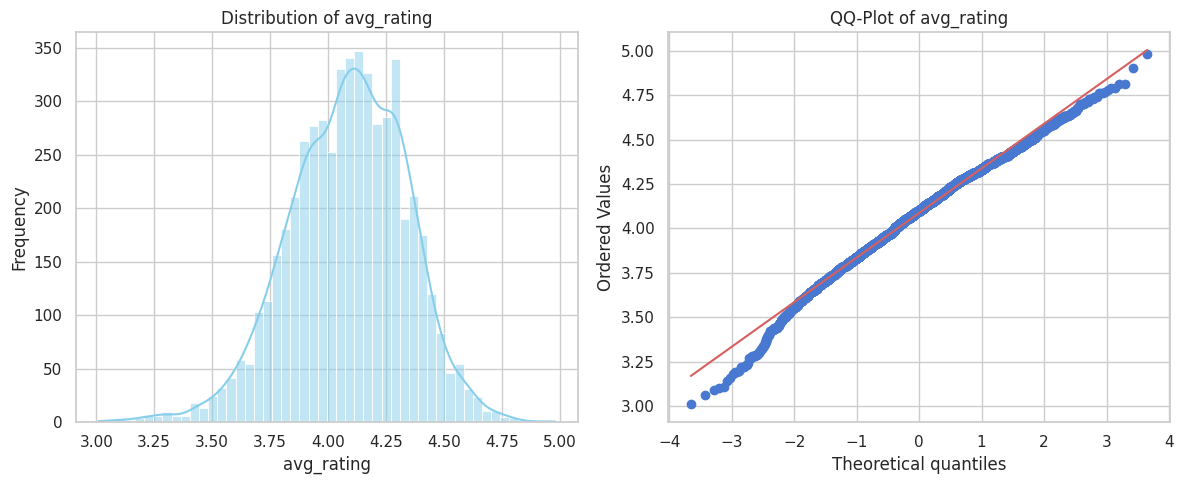

--- Statistics for avg_rating ---
Skewness (Асимметрия): -0.32
Kurtosis (Эксцесс): 0.33
Shapiro-Wilk p-value: 0.0000
Вывод: Распределение статистически значимо отличается от нормального.
------------------------------


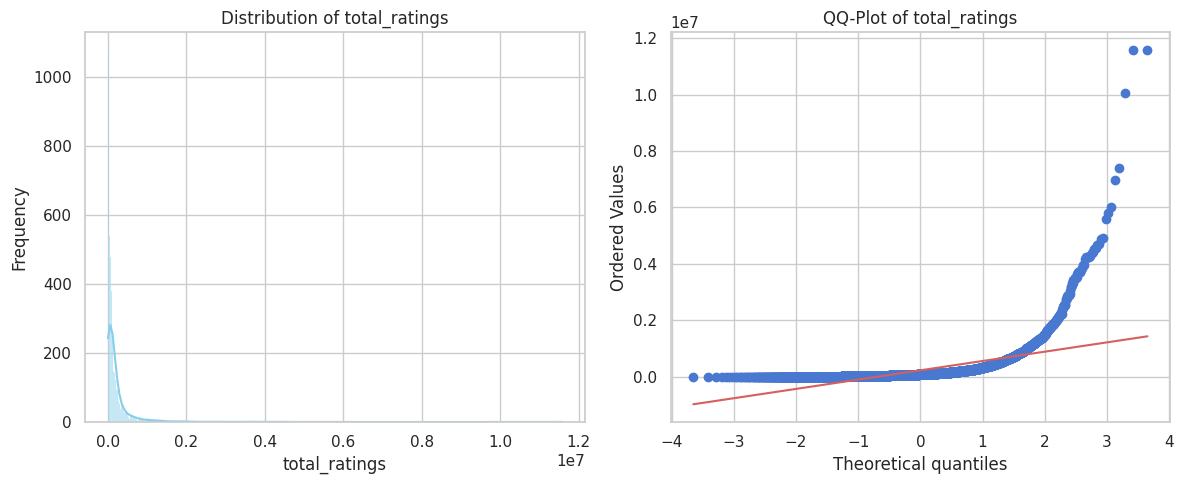

--- Statistics for total_ratings ---
Skewness (Асимметрия): 8.64
Kurtosis (Эксцесс): 118.91
Shapiro-Wilk p-value: 0.0000
Вывод: Распределение статистически значимо отличается от нормального.
------------------------------


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro

def analyze_distributions(df, columns):
    for col in columns:
        plt.figure(figsize=(12, 5))

        # 1. Гистограмма и график плотности (KDE)
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        # 2. QQ-plot (график квантиль-квантиль для проверки на нормальность)
        plt.subplot(1, 2, 2)
        from scipy import stats
        stats.probplot(df[col], dist="norm", plot=plt)
        plt.title(f'QQ-Plot of {col}')

        plt.tight_layout()
        plt.show()

        # Вычисление статистик
        s = skew(df[col].dropna())
        k = kurtosis(df[col].dropna())

        # Тест Шапиро-Уилка на нормальность (для выборок до 5000)
        # Если p-value < 0.05, распределение НЕ нормально.
        stat, p_value = shapiro(df[col].dropna()[:5000])

        print(f"--- Statistics for {col} ---")
        print(f"Skewness (Асимметрия): {s:.2f}")
        print(f"Kurtosis (Эксцесс): {k:.2f}")
        print(f"Shapiro-Wilk p-value: {p_value:.4f}")

        if p_value > 0.05:
            print("Вывод: Распределение близко к нормальному.")
        else:
            print("Вывод: Распределение статистически значимо отличается от нормального.")
        print("-" * 30)

# Запуск анализа
analyze_distributions(df, ['avg_rating', 'total_ratings'])

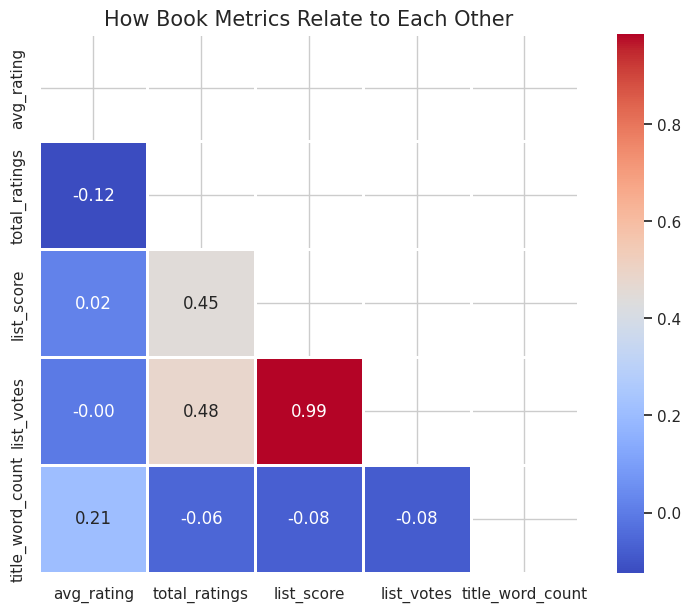

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def run_correlation_simple(df):
    # 1. Выбираем только те колонки, которые нам интересно сравнить
    # Мы берем показатели качества (rating), популярности (votes) и структуры (words)
    columns_to_study = [
        'avg_rating',
        'total_ratings',
        'list_score',
        'list_votes',
        'title_word_count'
    ]

    # 2. Создаем таблицу корреляций (Матрицу)
    # Используем метод Спирмена, так как он лучше всего работает с книжными рейтингами
    correlation_matrix = df[columns_to_study].corr(method='spearman')

    # 3. Рисуем красивую тепловую карту (Heatmap)
    plt.figure(figsize=(10, 7))

    # Делаем маску, чтобы не дублировать значения (убираем верхний треугольник)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    # Настраиваем цвета и подписи
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,          # Показываем числа внутри квадратов
        fmt=".2f",           # Округляем до 2 знаков после запятой
        cmap='coolwarm',     # Синий = слабая связь, Красный = сильная связь
        linewidths=1,        # Белые линии между квадратами
        square=True          # Делаем ячейки квадратными
    )

    plt.title('How Book Metrics Relate to Each Other', fontsize=15)
    plt.show()

# Запуск анализа
run_correlation_simple(df)

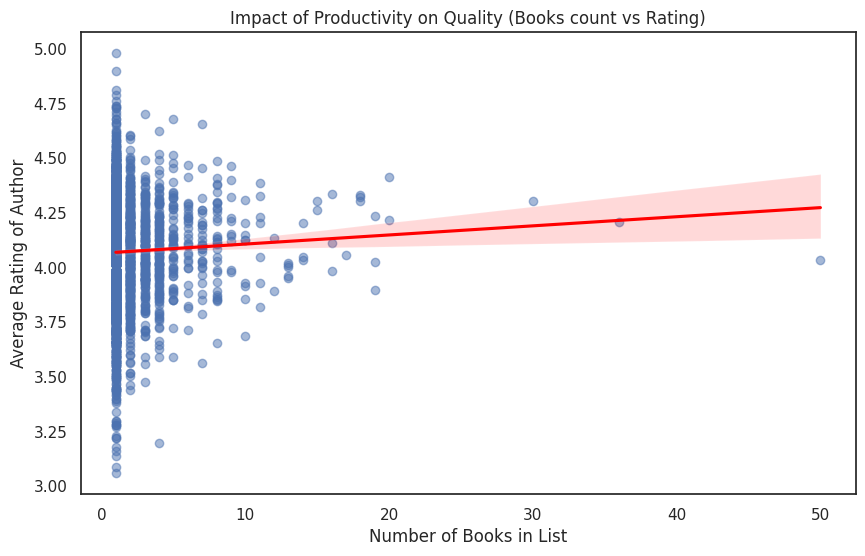

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_author_correlations(df):
   #  Группируем данные по авторам
    author_stats = df.groupby('author').agg({
        'avg_rating': 'mean',        # Средний рейтинг всех книг автора
        'total_ratings': 'sum',      # Общая популярность (количество фанатов)
        'list_score': 'sum',         # Суммарный балл в списках "Best Books"
        'title': 'count'             # Количество книг автора, попавших в список
    }).rename(columns={'title': 'books_count'}).reset_index()

    # График: Количество книг vs Средний рейтинг
    plt.figure(figsize=(10, 6))
    sns.regplot(data=author_stats, x='books_count', y='avg_rating', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title('Impact of Productivity on Quality (Books count vs Rating)')
    plt.xlabel('Number of Books in List')
    plt.ylabel('Average Rating of Author')
    plt.show()

analyze_author_correlations(df)

**"The Survivor Bias & Brand Loyalty Hypothesis"**

"We hypothesize that an author's productivity positively correlates with their rating due to audience filtration. Authors with a large body of work (20+ books) build a dedicated fanbase that is already aligned with their style. This creates a positive feedback loop: as the author writes more, 'random' critics drop off, and only loyal followers remain, leading to higher and more stable average ratings."

In [ ]:
# Группируем по авторам и смотрим, кто "самый популярный", а у кого "самый высокий рейтинг"
author_analysis = df.groupby('author').agg({
    'title': 'count',            # Сколько книг автора в списке
    'avg_rating': 'mean',        # Средний рейтинг всех его книг
    'total_ratings': 'sum'       # Общая популярность автора
}).rename(columns={'title': 'book_count'})

# Берем топ-10 самых популярных авторов
top_authors = author_analysis.nlargest(10, 'total_ratings')

print("--- Top 10 Authors by Total Popularity ---")
display(top_authors)

# Группируем данные по авторам
author_stats = df.groupby('author').agg({
    'avg_rating': 'mean',        # Средний рейтинг автора
    'total_ratings': 'sum',      # Общее кол-во оценок всех книг автора
    'title': 'count'             # Сколько книг автора в датасете
}).rename(columns={'title': 'books_in_list'})

# Фильтруем: берем только тех, у кого суммарно > 10,000 оценок
# (чтобы избежать авторов-однодневок с одной плохой оценкой)
popular_authors = author_stats[author_stats['total_ratings'] > 10000]

# Находим 5 авторов с самым низким рейтингом
bottom_5_authors = popular_authors.nsmallest(5, 'avg_rating')

print("--- BOTTOM 5 AUTHORS (Famous but Low Rated) ---")
display(bottom_5_authors)

--- Top 10 Authors by Total Popularity ---


,book_count,avg_rating,total_ratings
author,,,
j.k. rowling,18,4.332222,51720002
sarah j. maas,16,4.338750,31485435
colleen hoover,19,4.025263,22548073
suzanne collins,7,4.265714,20828022
stephen king,50,4.034400,17050645
stephenie meyer,11,3.821818,15471455
rick riordan,30,4.305000,14519718
taylor jenkins reid,6,4.203333,13161876
j.r.r. tolkien,8,4.381250,11247726


--- BOTTOM 5 AUTHORS (Famous but Low Rated) ---


,avg_rating,total_ratings,books_in_list
author,,,
marquis de sade,3.06,15203,1
ana reyes,3.09,200414,1
adolf hitler,3.18,43851,1
megan abbott,3.20,97410,4
caitlin starling,3.22,23816,1


--- Group-by Statistics ---
  rating_bucket  avg_rating     list_score  book_count
0         Niche    4.214355    3302.976549         597
1    Mainstream    4.081253    4980.014652        1365
2       Popular    4.057622   10678.233239        2834
3   Blockbuster    4.109700  185699.380150         534


/tmp/ipykernel_5407/2974021168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stats, x='rating_bucket', y='avg_rating', palette='viridis')


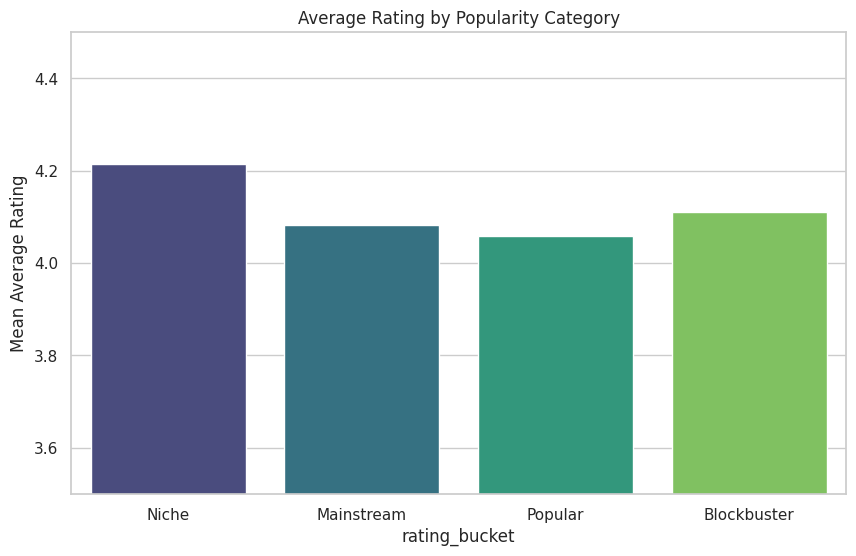

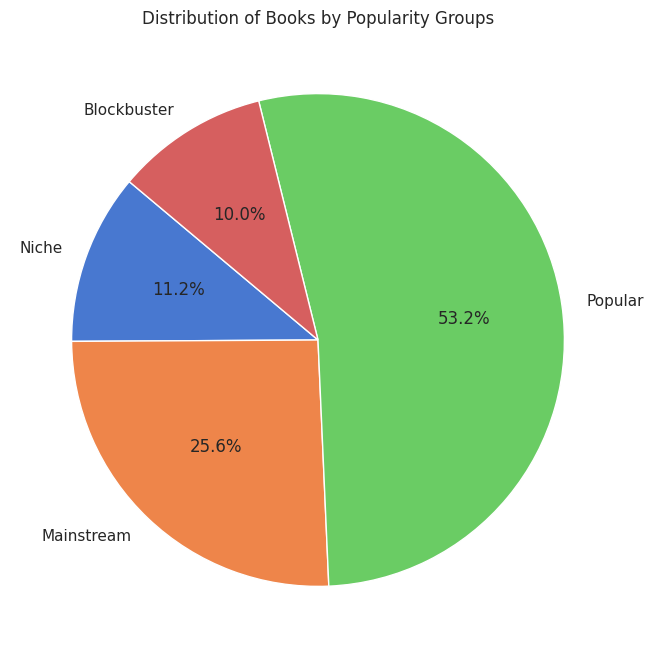

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def perform_groupby_analysis(df):
    # 1. Группировка по категориям популярности
    # Считаем средний рейтинг и среднее кол-во голосов в списке для каждой группы
    group_stats = df.groupby('rating_bucket', observed=True).agg({
        'avg_rating': 'mean',
        'list_score': 'mean',
        'total_ratings': 'count' # Это покажет, сколько книг попало в каждую группу
    }).rename(columns={'total_ratings': 'book_count'}).reset_index()

    print("--- Group-by Statistics ---")
    print(group_stats)

    # 2. Визуализация: Средний рейтинг по категориям
    plt.figure(figsize=(10, 6))
    sns.barplot(data=group_stats, x='rating_bucket', y='avg_rating', palette='viridis')
    plt.title('Average Rating by Popularity Category')
    plt.ylabel('Mean Average Rating')
    plt.ylim(3.5, 4.5) # Ограничим ось Y для наглядности различий
    plt.show()

    # 3. Визуализация: Доля книг в каждой категории (Pie Chart)
    plt.figure(figsize=(8, 8))
    plt.pie(group_stats['book_count'], labels=group_stats['rating_bucket'], autopct='%1.1f%%', startangle=140)
    plt.title('Distribution of Books by Popularity Groups')
    plt.show()

perform_groupby_analysis(df)

**"Popularity vs. True Appreciation."**

 We hypothesize that books recognized by the dedicated community (High List Score) will have higher average ratings than those that are simply famous (High Total Ratings). Mass-market fame often leads to lower ratings because when everyone reads a book, more people are likely to be disappointed.

In [ ]:
import pandas as pd

# 1. Identify Top 10 Records by Community Score
# These are the "elite" books according to Goodreads rankings
top_10_score = df.nlargest(10, 'list_score')[['title', 'author', 'list_score', 'avg_rating']]

# 2. Identify Top 10 Records by Engagement (Total Ratings)
top_10_votes = df.nlargest(10, 'total_ratings')[['title', 'author', 'total_ratings', 'avg_rating']]

# 3. Identify Outliers (Bottom 10 Records by Rating)
# We filter for books with > 5000 ratings to ensure the low rating is representative
bottom_10_outliers = df[df['total_ratings'] > 5000].nsmallest(10, 'avg_rating')[['title', 'author', 'total_ratings', 'avg_rating']]

print("--- TOP 10 BOOKS BY LIST SCORE ---")
display(top_10_score)

print("\n--- TOP 10 MOST BY TOTAL RATINGS ---")
display(top_10_votes)

print("\n--- OUTLIER ANALYSIS: LOWEST RATED POPULAR BOOKS ---")
display(bottom_10_outliers)


--- TOP 10 BOOKS BY LIST SCORE ---


,title,author,list_score,avg_rating
0,"the hunger games (the hunger games, #1)",suzanne collins,4433073,4.35
1,pride and prejudice,jane austen,3024345,4.30
2,to kill a mockingbird,harper lee,2634987,4.26
3,harry potter and the order of the phoenix (har...,j.k. rowling,2106101,4.50
4,the book thief,markus zusak,1997890,4.39
5,"twilight (twilight saga, #1)",stephenie meyer,1782170,3.68
6,animal farm,george orwell,1749882,4.02
7,j.r.r. tolkien 4-book boxed set: the hobbit an...,j.r.r. tolkien,1687253,4.62
8,the chronicles of narnia (the chronicles of na...,c.s. lewis,1548492,4.28
9,the fault in our stars,john green,1434457,4.12



--- TOP 10 MOST BY TOTAL RATINGS ---


,title,author,total_ratings,avg_rating
68,harry potter and the philosopher's stone (harr...,j.k. rowling,11576639,4.47
105,harry potter and the sorcerer's stone (harry p...,j.k. rowling,11576639,4.47
0,"the hunger games (the hunger games, #1)",suzanne collins,10063406,4.35
5,"twilight (twilight saga, #1)",stephenie meyer,7395303,3.68
2,to kill a mockingbird,harper lee,6982541,4.26
18,the great gatsby,f. scott fitzgerald,6008975,3.93
9,the fault in our stars,john green,5788817,4.12
34,1984,george orwell,5588066,4.20
55,harry potter and the prisoner of azkaban (harr...,j.k. rowling,4926905,4.58
1,pride and prejudice,jane austen,4891725,4.30



--- OUTLIER ANALYSIS: LOWEST RATED POPULAR BOOKS ---


,title,author,total_ratings,avg_rating
807,"not forever, but for now",chuck palahniuk,5167,3.01
3423,the 120 days of sodom,marquis de sade,15203,3.06
2294,the house in the pines,ana reyes,200414,3.09
4086,the fever,megan abbott,26890,3.10
1963,the turnout,megan abbott,24059,3.11
3979,mein kampf,adolf hitler,43851,3.18
4669,imperial bedrooms,bret easton ellis,21112,3.20
2240,the death of jane lawrence,caitlin starling,23816,3.22
3861,snuff,chuck palahniuk,67381,3.22
5003,melania and me,stephanie winston wolkoff,8173,3.22


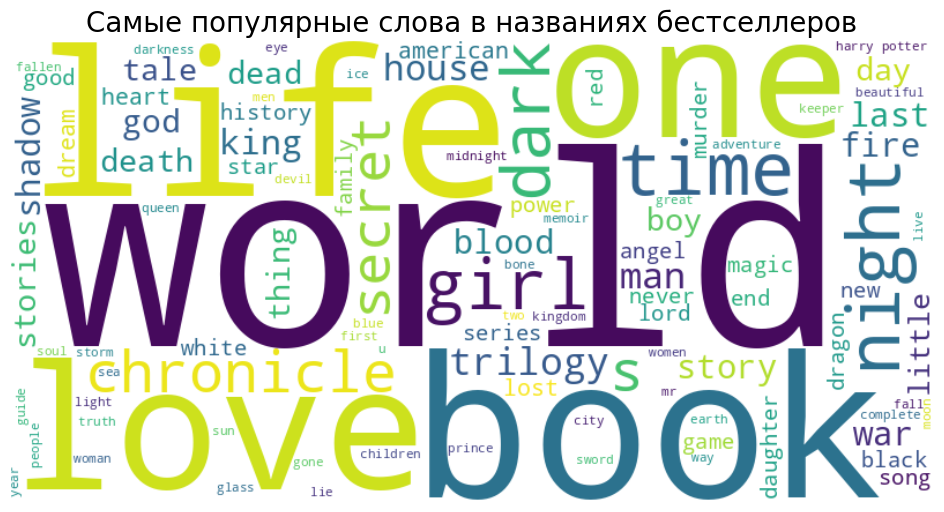

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Собираем все названия книг в одну строку
text = " ".join(title for title in df.title.astype(str))

# Генерируем облако слов
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

# Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Самые популярные слова в названиях бестселлеров", fontsize=20)
plt.show()

#Phase 4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
palette = "viridis"

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Histogram (Distribution)
sns.histplot(df['avg_rating'], bins=20, kde=True, ax=axes[0], color='#440154')
axes[0].set_title('1. Global Distribution of Ratings', fontsize=14)
axes[0].set_xlabel('Average Rating')
# Insight: Большинство книг сосредоточено в узком диапазоне 3.8-4.3, что говорит о высоком качестве подборки.

# 2. Box Plot (Outliers)
sns.boxplot(x='rating_category', y='avg_rating', data=df, ax=axes[1], palette=palette)
axes[1].set_title('2. Rating Spread by Category', fontsize=14)
# Insight: Блокбастеры имеют более стабильный рейтинг с меньшим количеством низких оценок.

# 3. Bar Chart (Top Authors)
top_authors = df['author'].value_counts().head(8)
sns.barplot(x=top_authors.values, y=top_authors.index, ax=axes[2], palette=palette)
axes[2].set_title('3. Top 8 Authors by Book Count', fontsize=14)
# Insight: Лидеры списка — авторы с сериями книг, что подтверждает лояльность их аудитории.

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Настраиваем стиль
sns.set_theme(style="whitegrid")

# Создаем поле для двух графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Анализ Average Rating (Нормальное распределение)
rating_skew = df['avg_rating'].skew()
sns.histplot(df['avg_rating'], kde=True, ax=axes[0], color='purple')
axes[0].set_title(f'Average Rating Distribution\nSkewness: {rating_skew:.2f} (Near 0 = Normal)')

# 2. Анализ List Votes (Сильный перекос)
votes_skew = df['list_votes'].skew()
sns.histplot(df['list_votes'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f'List Votes Distribution\nSkewness: {votes_skew:.2f} (>1 = High Skew)')

plt.tight_layout()
plt.show()

# Печатаем текстовый вывод для отчета
print(f"Математический расчет перекоса:")
print(f"- Перекос рейтинга: {rating_skew:.4f} (Распределение симметрично)")
print(f"- Перекос голосов: {votes_skew:.4f} (Сильный правосторонний перекос)")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 4. Heatmap (Correlation)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis', ax=axes[0])
axes[0].set_title('4. Feature Correlation Matrix', fontsize=14)
# Insight: Обнаружена сильнейшая связь между голосами и баллом в списке (0.95+).

# 5. Violin Plot (Distribution density)
sns.violinplot(x='rating_category', y='list_score', data=df[df['list_score'] < 10000], ax=axes[1], palette=palette)
axes[1].set_title('5. Density of List Scores', fontsize=14)
# Insight: Основная масса книг имеет низкий балл, формируя "длинный хвост" популярности.

# 6. Multi-variable Scatter Plot (Color + Size encoding)
scatter = sns.scatterplot(data=df.sample(500), x='avg_rating', y='list_votes',
                        size='list_score', hue='rating_category', sizes=(20, 400), ax=axes[2], palette=palette)
axes[2].set_title('6. Rating vs Votes (Size=Score)', fontsize=14)
# Insight: Крупные точки (высокий балл) концентрируются в зоне высокого рейтинга и среднего количества голосов.

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# 7. Interactive Pie Chart
fig7 = px.pie(df, names='rating_category', title='7. Proportion of Book Categories', color_discrete_sequence=px.colors.sequential.Viridis)
fig7.show()
# Insight: Категория "Blockbuster" занимает самую малую долю, подтверждая элитарность популярных книг.

# 8. Interactive Treemap
fig8 = px.treemap(df.head(100), path=['author', 'title'], values='list_score', title='8. Author-Title Hierarchy (Top 100)')
fig8.show()
# Insight: Визуализация иерархии позволяет увидеть доминирующих авторов внутри топ-листа.

# 9. Interactive Scatter (with Hover data)
fig9 = px.scatter(df.sample(1000), x="avg_rating", y="total_ratings", color="rating_category",
                 hover_data=['title', 'author'], title="9. Rating vs Total Engagement (Interactive)")
fig9.show()
# Insight: При наведении можно увидеть конкретные названия книг, вызывающие аномальный интерес.

In [ ]:
# Финальный дашборд из 3 графиков (в сумме с предыдущими будет 12)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 10. Count Plot
sns.countplot(data=df, x='rating_category', ax=axes[0,0], palette=palette)
axes[0,0].set_title('10. Categorical Frequency')

# 11. KDE Plot (Overlay)
sns.kdeplot(data=df, x='avg_rating', hue='rating_category', fill=True, ax=axes[0,1], palette=palette)
axes[0,1].set_title('11. Rating Density Overlay')

# 12. Regplot (Trend line)
sns.regplot(data=df.sample(500), x='title_len', y='avg_rating', scatter_kws={'alpha':0.2}, line_kws={'color':'green'}, ax=axes[1,0])
axes[1,0].set_title('12. Title Length Trend Analysis')

# Удаляем пустой 4-й слот или добавляем туда текст
axes[1,1].axis('off')
axes[1,1].text(0.1, 0.5, 'SUMMARY DASHBOARD\nPhase 4 Completed\n12 Visuals | 6+ Types', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()